# Tiny Companion: KS Test for Drift

This notebook is a small companion for the KS-test part of Week 10.

We will look at just two cases:

1. a case with **no real drift**
2. a case with **clear drift**

The goal is to understand the plots first, then the statistic `D`, and only then the `p-value`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
%config InlineBackend.figure_format = 'retina'


## Helper: plot histogram and CDF together

This makes it easier to see the task:

- histogram: what the feature distribution looks like
- CDF: a smoother running-total view of the same data


In [2]:
def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


def plot_case(train, prod, title):
    stat, p = ks_2samp(train, prod)
    x1, y1 = ecdf(train)
    x2, y2 = ecdf(prod)

    all_values = np.sort(np.concatenate([train, prod]))
    y1i = np.searchsorted(x1, all_values, side='right') / len(x1)
    y2i = np.searchsorted(x2, all_values, side='right') / len(x2)
    gaps = np.abs(y1i - y2i)
    idx = np.argmax(gaps)
    x_gap = all_values[idx]
    y_gap_1 = y1i[idx]
    y_gap_2 = y2i[idx]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(train, bins=25, alpha=0.6, color='steelblue', density=True, label='Training')
    axes[0].hist(prod, bins=25, alpha=0.6, color='coral', density=True, label='Production')
    axes[0].set_title(f'{title}: Histogram')
    axes[0].legend()

    axes[1].plot(x1, y1, color='steelblue', linewidth=2.2, label='Training CDF')
    axes[1].plot(x2, y2, color='coral', linewidth=2.2, label='Production CDF')
    axes[1].annotate('', xy=(x_gap, y_gap_1), xytext=(x_gap, y_gap_2),
                     arrowprops=dict(arrowstyle='<->', color='#c44536', lw=2))
    axes[1].text(x_gap, (y_gap_1 + y_gap_2)/2, f'  D = {stat:.3f}', color='#c44536',
                 va='center', fontsize=11, fontweight='bold')
    axes[1].set_title(f'{title}: CDF')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print(f'KS statistic D = {stat:.3f}')
    print(f'p-value        = {p:.4f}')


## Case 1: No Real Drift

Here the production data is sampled from almost the same distribution as training.

Expectation:

- histograms should look similar
- CDFs should stay close
- `D` should be small
- `p-value` should not be especially small


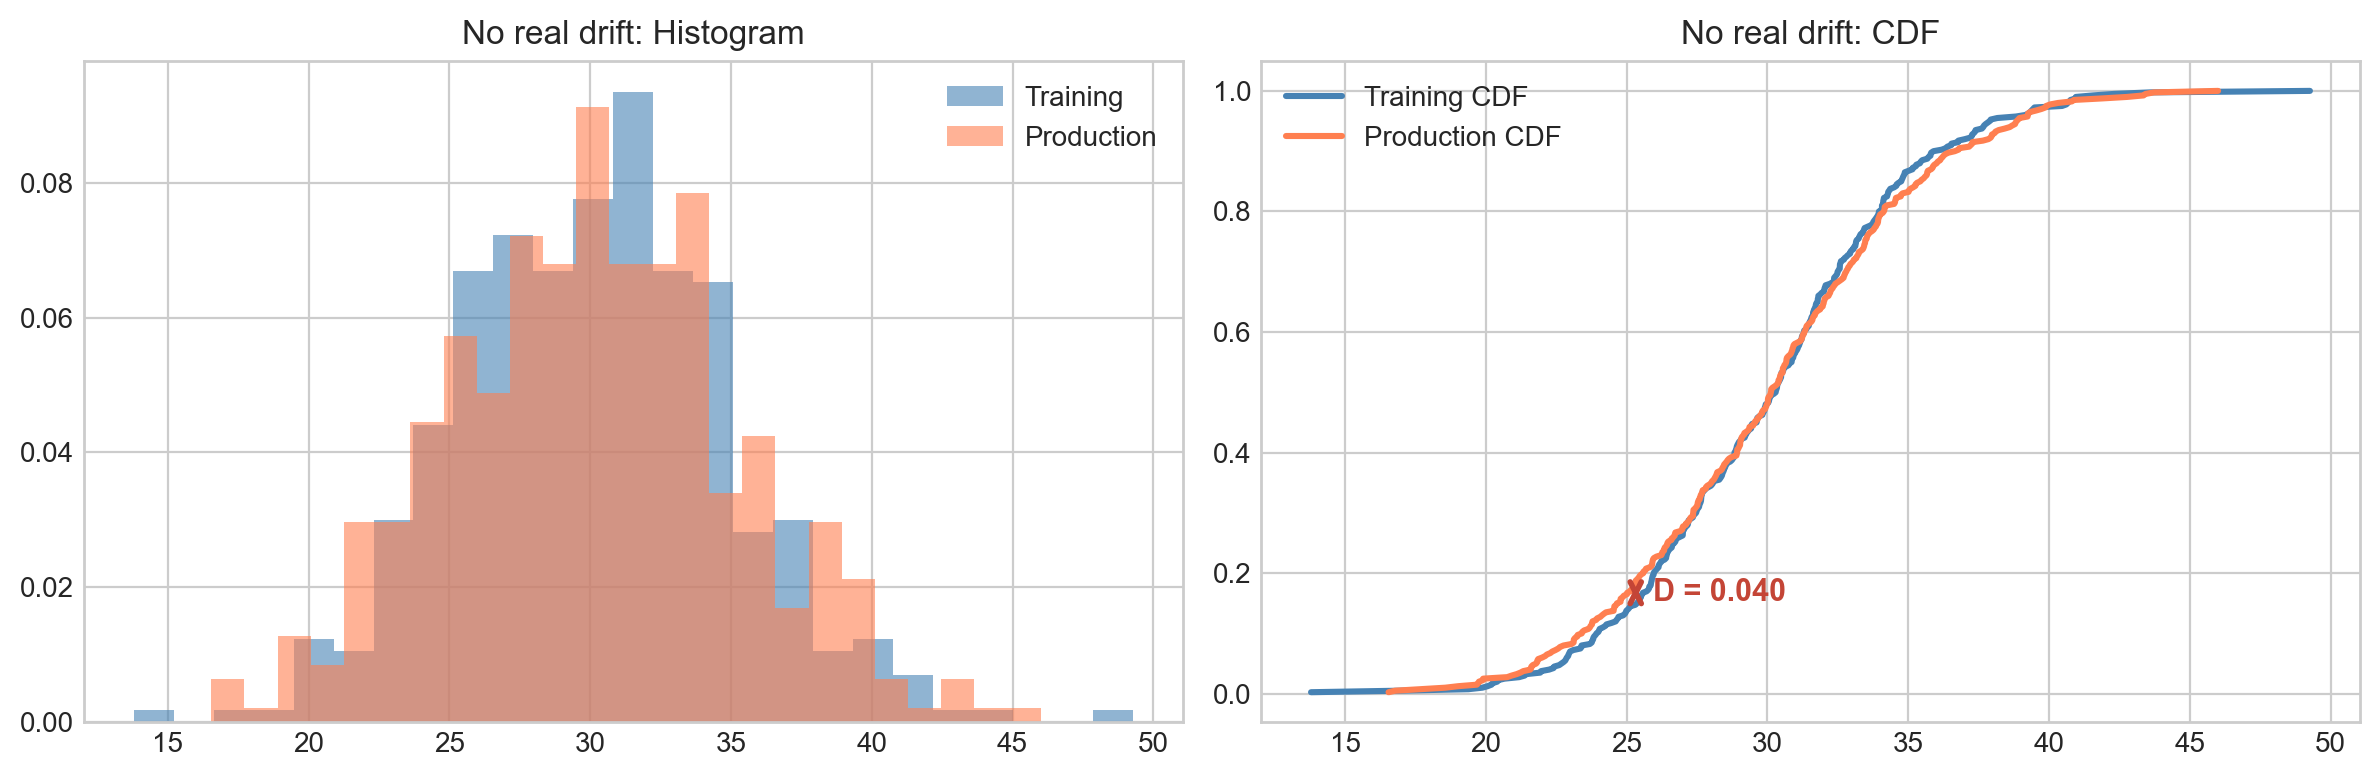

KS statistic D = 0.040
p-value        = 0.9068


In [3]:
train = np.random.normal(30, 5, 400)
prod_no_drift = np.random.normal(30.3, 5.1, 400)
plot_case(train, prod_no_drift, 'No real drift')

## Case 2: Clear Drift

Now the production data really has shifted.

Expectation:

- histograms should move apart
- CDFs should separate clearly
- `D` should be larger
- `p-value` should become very small


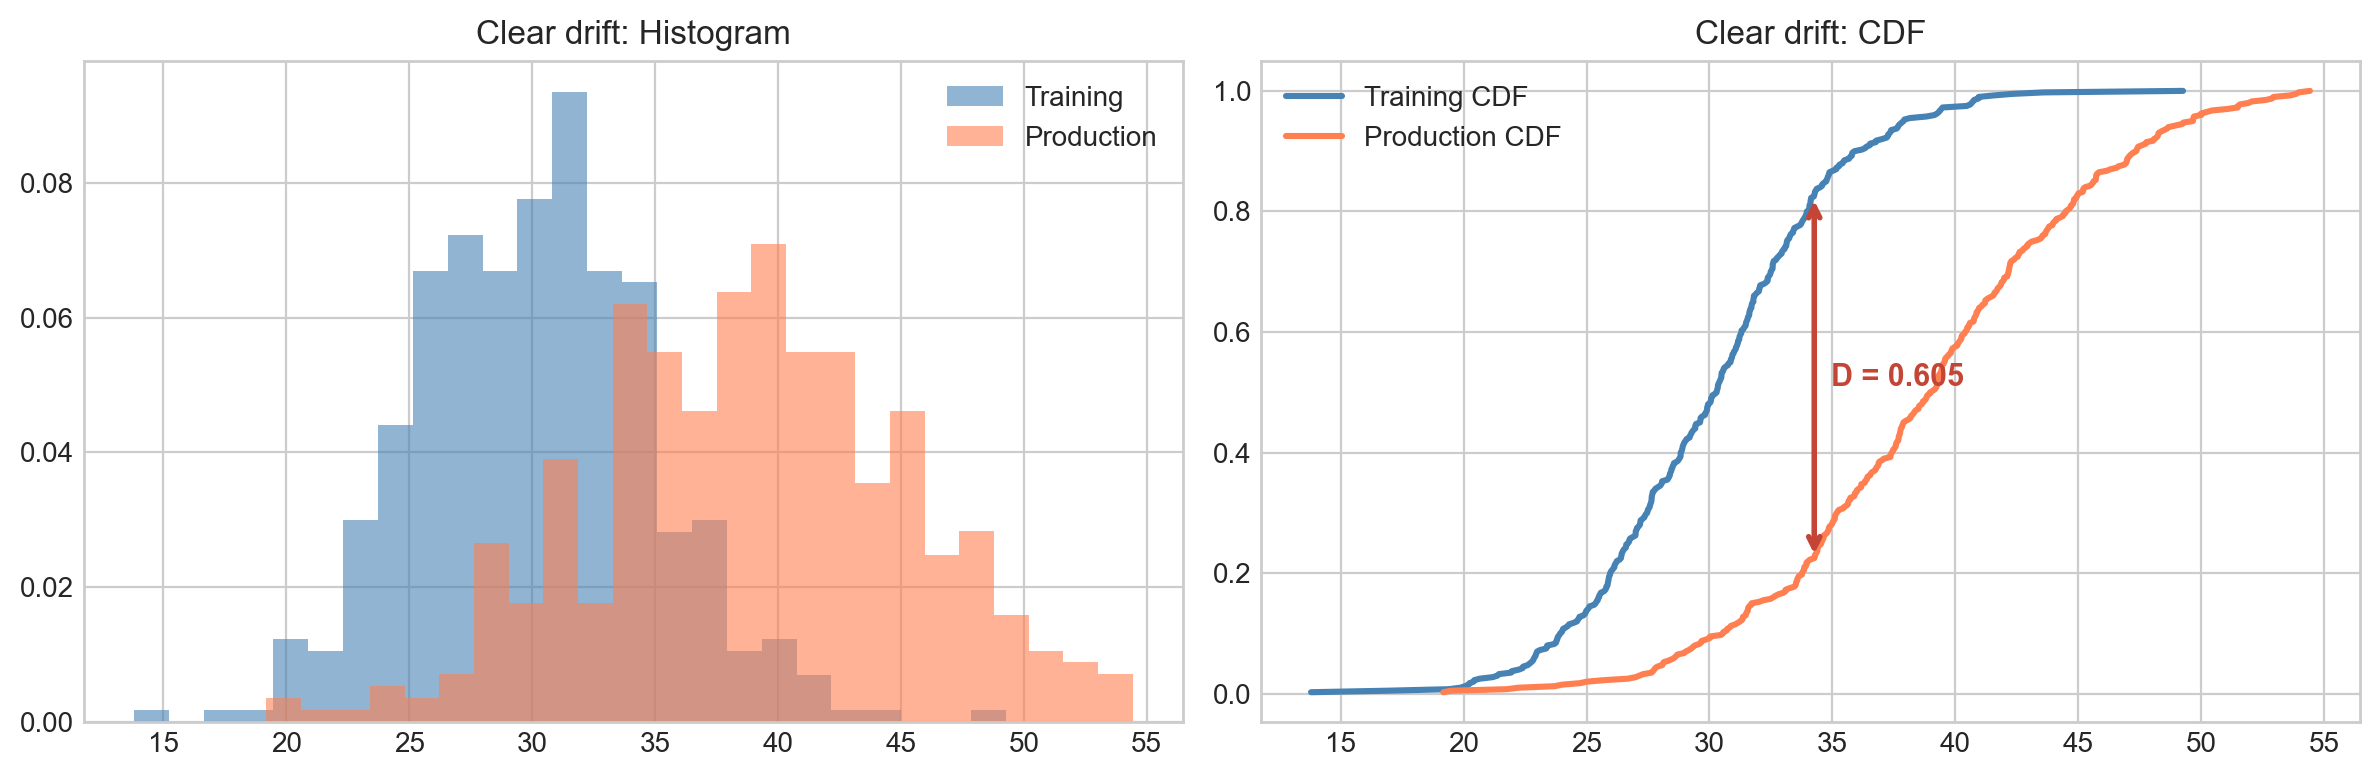

KS statistic D = 0.605
p-value        = 0.0000


In [4]:
prod_drift = np.random.normal(38, 6.5, 400)
plot_case(train, prod_drift, 'Clear drift')

## How to Explain p-value Gently

You do not need a deep statistics course here.

Use this sentence:

> If there were really no drift, how surprising would a gap this large be just because of random sampling?

So:

- **large p-value**: a gap like this could happen by chance
- **small p-value**: a gap like this is hard to explain by chance alone

That is enough intuition for this course.


## Takeaway

When teaching or debugging drift:

1. show the histogram first
2. show the CDF next
3. say that `D` is the biggest vertical gap
4. explain `p-value` only after the picture is clear
